# 01 — EDA: Dataset de Placas Vehiculares
**Proyecto:** Placas-Deteccion-Robo (v2 simplificada — visión con YOLO + OCR)
**Punto del PDF:** 1) Definición del Dataset, 2) Análisis Exploratorio de Datos (EDA)

**Dataset elegido:** [Car License Plate Detection](https://www.kaggle.com/datasets/andrewmvd/car-plate-detection) (Kaggle, andrewmvd).
- ~433 imágenes con 1 placa anotada por imagen.
- Anotaciones en formato **Pascal VOC (XML)**, una por imagen, en `annotations/`.
- Imágenes en `images/`.
- Se usa el dataset completo (~433 imágenes) ya que cae dentro del rango sugerido en el plan (300–800 imágenes) sin necesidad de recortarlo.

> Correr este notebook en **Google Colab** con GPU (Entorno de ejecución → Cambiar tipo de entorno → GPU).


### 1.1 Instalación de dependencias y credenciales de Kaggle

In [1]:
!pip install -q kaggle ultralytics opencv-python-headless matplotlib pandas



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Kaggle API: hace falta un kaggle.json (Kaggle > Account > Create New API Token).
# En Colab lo sube por el selector de archivos; corriendo local (venv) lo toma
# directo de ~/.kaggle/kaggle.json (Windows: C:\Users\<usuario>\.kaggle\kaggle.json),
# que es donde el CLI de Kaggle lo espera siempre.
import os

try:
    from google.colab import files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

kaggle_dir = os.path.expanduser('~/.kaggle')
kaggle_json = os.path.join(kaggle_dir, 'kaggle.json')

if not os.path.exists(kaggle_json):
    if IN_COLAB:
        uploaded = files.upload()  # selecciona kaggle.json
        os.makedirs(kaggle_dir, exist_ok=True)
        for fname in uploaded:
            os.rename(fname, kaggle_json)
        os.chmod(kaggle_json, 0o600)
    else:
        raise FileNotFoundError(
            f"No se encontró {kaggle_json}. Corriendo local: descargá tu token en "
            "https://www.kaggle.com/settings > API > Create New Token, y guardá el "
            "kaggle.json descargado en esa ruta antes de re-ejecutar esta celda."
        )


### 1.2 Descarga del dataset

In [3]:
!kaggle datasets download -d andrewmvd/car-plate-detection -p data/raw --unzip


Dataset URL: https://www.kaggle.com/datasets/andrewmvd/car-plate-detection
License(s): CC0-1.0




  0%|          | 0.00/203M [00:00<?, ?B/s]
 60%|█████▉    | 121M/203M [00:00<00:00, 1.26GB/s]
100%|██████████| 203M/203M [00:02<00:00, 106MB/s] 


In [4]:
import os

RAW_DIR = 'data/raw'
IMAGES_DIR = os.path.join(RAW_DIR, 'images')
ANNOT_DIR = os.path.join(RAW_DIR, 'annotations')

img_files = sorted(os.listdir(IMAGES_DIR))
ann_files = sorted(os.listdir(ANNOT_DIR))

print(f'Imágenes: {len(img_files)}')
print(f'Anotaciones: {len(ann_files)}')
print('Ejemplo imagen:', img_files[:3])
print('Ejemplo anotación:', ann_files[:3])


Imágenes: 433
Anotaciones: 433
Ejemplo imagen: ['Cars0.png', 'Cars1.png', 'Cars10.png']
Ejemplo anotación: ['Cars0.xml', 'Cars1.xml', 'Cars10.xml']


### 1.3 Parseo de anotaciones Pascal VOC (XML) a un DataFrame

Se extrae: nombre de imagen, ancho/alto de la imagen, y bbox de la placa (`xmin, ymin, xmax, ymax`).

In [5]:
import xml.etree.ElementTree as ET
import pandas as pd

def parse_voc_xml(xml_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()
    filename = root.find('filename').text
    size = root.find('size')
    width = int(size.find('width').text)
    height = int(size.find('height').text)

    boxes = []
    for obj in root.findall('object'):
        bbox = obj.find('bndbox')
        xmin = int(bbox.find('xmin').text)
        ymin = int(bbox.find('ymin').text)
        xmax = int(bbox.find('xmax').text)
        ymax = int(bbox.find('ymax').text)
        boxes.append((xmin, ymin, xmax, ymax))
    return filename, width, height, boxes

records = []
for ann in ann_files:
    filename, width, height, boxes = parse_voc_xml(os.path.join(ANNOT_DIR, ann))
    for (xmin, ymin, xmax, ymax) in boxes:
        bw, bh = xmax - xmin, ymax - ymin
        records.append({
            'filename': filename,
            'img_width': width,
            'img_height': height,
            'xmin': xmin, 'ymin': ymin, 'xmax': xmax, 'ymax': ymax,
            'bbox_width': bw, 'bbox_height': bh,
            'bbox_area': bw * bh,
            'bbox_area_ratio': (bw * bh) / (width * height),
            'aspect_ratio': bw / bh if bh > 0 else None,
        })

df = pd.DataFrame(records)
df.head()


,filename,img_width,img_height,xmin,ymin,xmax,ymax,bbox_width,bbox_height,bbox_area,bbox_area_ratio,aspect_ratio
0,Cars0.png,500,268,226,125,419,173,193,48,9264,0.069134,4.020833
1,Cars1.png,400,248,134,128,262,160,128,32,4096,0.041290,4.000000
2,Cars10.png,400,225,140,5,303,148,163,143,23309,0.258989,1.139860
3,Cars100.png,400,267,175,114,214,131,39,17,663,0.006208,2.294118
4,Cars101.png,400,300,167,202,240,220,73,18,1314,0.010950,4.055556


### 1.4 Estadísticas descriptivas (variables, tipos, distribuciones)

In [6]:
print(df.dtypes)
print()
print(f'Total de placas anotadas: {len(df)}')
print(f'Imágenes con más de 1 placa: {df.filename.value_counts().gt(1).sum()}')
df.describe()


filename            object
img_width            int64
img_height           int64
xmin                 int64
ymin                 int64
xmax                 int64
ymax                 int64
bbox_width           int64
bbox_height          int64
bbox_area            int64
bbox_area_ratio    float64
aspect_ratio       float64
dtype: object

Total de placas anotadas: 471
Imágenes con más de 1 placa: 24


,img_width,img_height,xmin,ymin,xmax,ymax,bbox_width,bbox_height,bbox_area,bbox_area_ratio,aspect_ratio
count,471.000000,471.000000,471.000000,471.000000,471.000000,471.000000,471.000000,471.000000,471.000000,471.000000,471.000000
mean,423.299363,290.205945,167.535032,161.942675,265.322718,197.118896,97.787686,35.176221,5245.980892,0.040545,2.960149
std,66.453996,65.612613,86.167639,53.624095,95.529309,51.388453,76.418873,29.721486,11114.082925,0.076491,1.144362
min,225.000000,141.000000,0.000000,5.000000,27.000000,65.000000,9.000000,5.000000,45.000000,0.000454,0.727273
25%,400.000000,246.000000,107.000000,127.000000,215.000000,162.000000,47.500000,19.000000,889.000000,0.008335,2.000000
50%,400.000000,270.000000,158.000000,163.000000,261.000000,195.000000,76.000000,27.000000,2220.000000,0.018305,2.857143
75%,400.000000,301.000000,222.000000,193.000000,319.000000,224.500000,128.000000,39.500000,4766.500000,0.037706,3.836667
max,600.000000,531.000000,541.000000,405.000000,598.000000,439.000000,486.000000,240.000000,116640.000000,0.777600,6.571429


### 1.5 Valores faltantes

In [7]:
missing_imgs = set(img_files) - set(df.filename.unique())
missing_anns = set([f.replace('.xml', '.png') for f in ann_files]) - set(df.filename.unique())
print(f'Imágenes sin anotación (huérfanas): {len(missing_imgs)}')
print(f'Nulos por columna:')
print(df.isnull().sum())


Imágenes sin anotación (huérfanas): 0
Nulos por columna:
filename           0
img_width          0
img_height         0
xmin               0
ymin               0
xmax               0
ymax               0
bbox_width         0
bbox_height        0
bbox_area          0
bbox_area_ratio    0
aspect_ratio       0
dtype: int64


### 1.6 Distribuciones: tamaño de bbox, relación de aspecto, área relativa

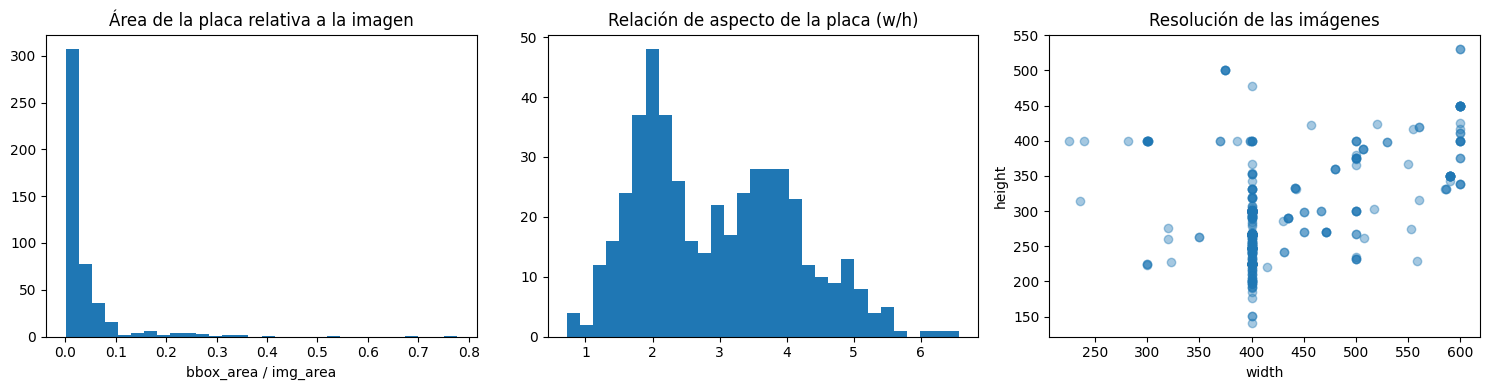

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df['bbox_area_ratio'], bins=30)
axes[0].set_title('Área de la placa relativa a la imagen')
axes[0].set_xlabel('bbox_area / img_area')

axes[1].hist(df['aspect_ratio'], bins=30)
axes[1].set_title('Relación de aspecto de la placa (w/h)')

axes[2].scatter(df['img_width'], df['img_height'], alpha=0.4)
axes[2].set_title('Resolución de las imágenes')
axes[2].set_xlabel('width')
axes[2].set_ylabel('height')

plt.tight_layout()
plt.show()


### 1.7 Correlaciones entre variables numéricas

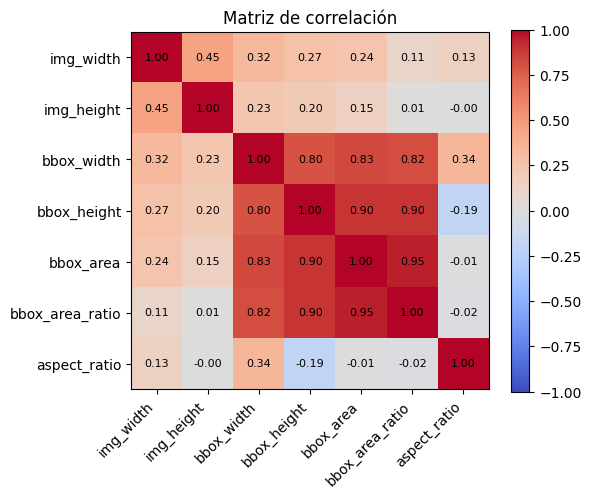

In [9]:
import numpy as np

corr_cols = ['img_width', 'img_height', 'bbox_width', 'bbox_height', 'bbox_area', 'bbox_area_ratio', 'aspect_ratio']
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_cols))); ax.set_xticklabels(corr_cols, rotation=45, ha='right')
ax.set_yticks(range(len(corr_cols))); ax.set_yticklabels(corr_cols)
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=8)
plt.colorbar(im)
plt.title('Matriz de correlación')
plt.tight_layout()
plt.show()


### 1.8 Visualización de muestras con su bounding box

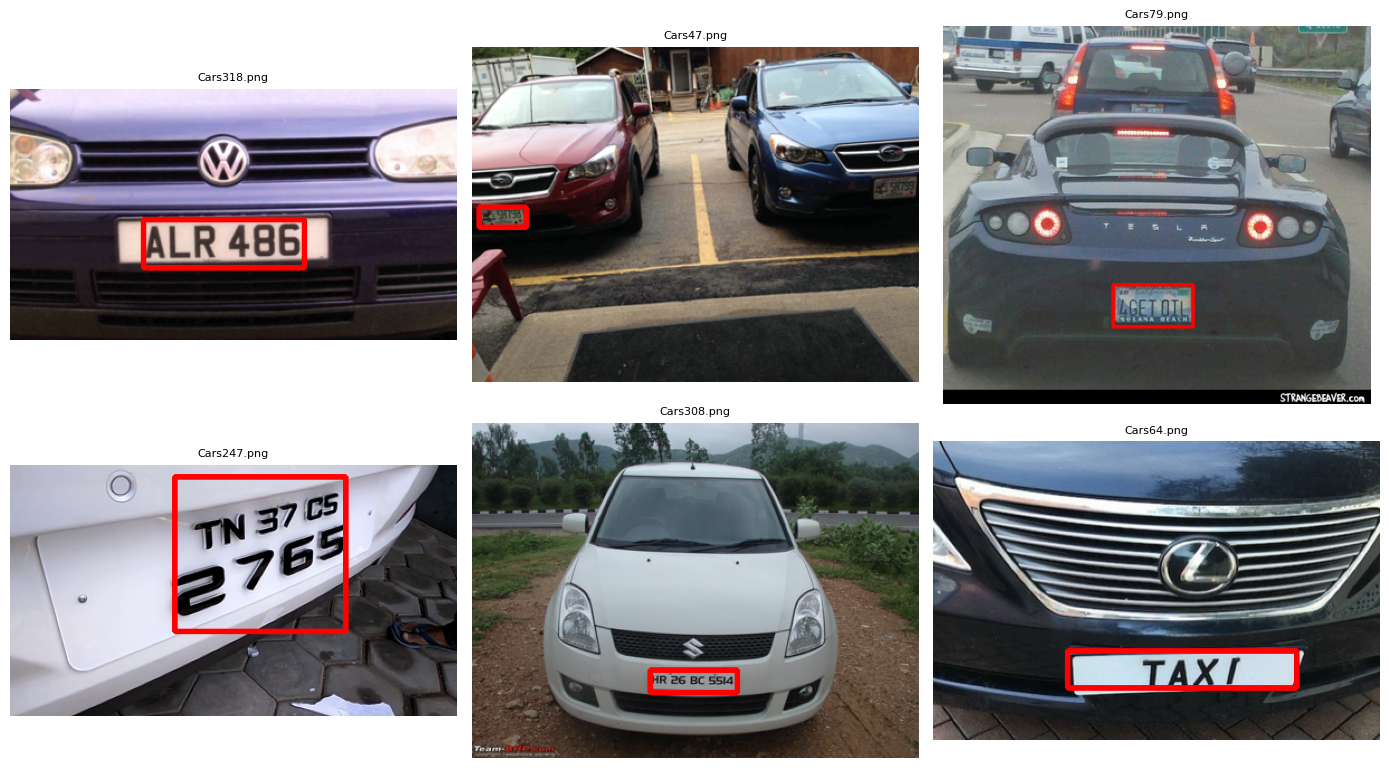

In [10]:
import cv2
import random

def draw_sample(filename, ax):
    img_path = os.path.join(IMAGES_DIR, filename)
    img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    rows = df[df.filename == filename]
    for _, r in rows.iterrows():
        cv2.rectangle(img, (r.xmin, r.ymin), (r.xmax, r.ymax), (255, 0, 0), 3)
    ax.imshow(img)
    ax.set_title(filename, fontsize=8)
    ax.axis('off')

sample_files = random.sample(list(df.filename.unique()), 6)
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for f, ax in zip(sample_files, axes.flatten()):
    draw_sample(f, ax)
plt.tight_layout()
plt.show()


### 1.9 Conclusiones del EDA (completar en el informe técnico)

- Nº total de imágenes / placas anotadas: `<completar con el output de 1.3>`
- Rango típico de área relativa de la placa (¿placas chicas o grandes dentro de la imagen?): `<completar>`
- Relación de aspecto típica de una placa (debería rondar valores tipo 2:1 a 4:1): `<completar>`
- Imágenes huérfanas / anotaciones faltantes encontradas: `<completar>`
- Implicancia para el modelo: dataset con 1 clase (`placa`), tamaño manejable para fine-tuning rápido de YOLOv8n en pocas épocas.
